# 05 — Evaluation, Interpretation & Personal Validation

This notebook covers all Day 4 work:
1. Comprehensive model comparison (Riegel, VDOT, Linear, RF, XGBoost/LGBM)
2. SHAP interpretability analysis for the best model
3. Personal Strava data validation (n=1)
4. Error analysis and model limitations

**Depends on:** Trained models from `04_model_training.ipynb`, processed data from `data/processed/`.

## Setup

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import joblib


from src.evaluate import regression_metrics, comparison_table
from src.baselines import riegel_predict, vdot_from_race, vdot_predict

sns.set_theme(style='whitegrid')
%matplotlib inline

## Load test data and trained models

In [8]:
# Load train/test splits
train = pd.read_parquet('../data/processed/train.parquet')
test = pd.read_parquet('../data/processed/test.parquet')

# Define X and y for test set
feature_cols = [
    "age",
    "bmi",
    "female",
    "injury",
    "footwear",
    "mh_ti_adj_final",
    "mh_ti_adj_imputed_flag",
    "tempo",
    "sprint",
    "typical",
    "mean_vdot",
    "vdot_consistency",
]
X_test = test[feature_cols]
y_test = test['mf_ti_adj']

print(f'Train: {train.shape}, Test: {test.shape}')

Train: (388, 14), Test: (97, 14)


In [9]:
# Load trained models 
lr_model = joblib.load('../models/linear_regression.pkl')
rf_model = joblib.load('../models/random_forest_tuned.pkl')
gb_model = joblib.load('../models/gradient_boosting_tuned.pkl')

---

## Part 1: Comprehensive model comparison

Compare all models and baselines on the test set using the same metrics: MAE, RMSE, MAPE, R2

### Generate predictions from all models

In [13]:
# Baseline predictions on test set
riegel_preds = test.apply(
    lambda row: riegel_predict(row["mh_ti_adj_final"], 13.1, 26.2), axis=1
)

vdot_preds = test.apply(
    lambda row: vdot_predict(row["mean_vdot"], 26.2), axis=1
)

# ML model predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
gb_preds = gb_model.predict(X_test)

### Final comparison table

In [15]:
# Build results dict and display comparison
results = {
    'VDOT': regression_metrics(y_test, vdot_preds),
    'Riegel': regression_metrics(y_test, riegel_preds),
    'Linear Regression': regression_metrics(y_test, lr_preds),
    'Random Forest': regression_metrics(y_test, rf_preds),
    'Gradient Boosting': regression_metrics(y_test, gb_preds),
}
comparison_table(results)

                     MAE   RMSE  MAPE      R2
Model                                        
VDOT               18.10  22.96  7.45  0.7307
Riegel             16.64  22.27  6.84  0.7466
Linear Regression  11.04  14.81  4.62  0.8879
Random Forest      10.10  14.46  4.16  0.8932
Gradient Boosting   9.86  14.07  4.02  0.8988


,MAE,RMSE,MAPE,R2
Model,,,,
VDOT,18.10,22.96,7.45,0.7307
Riegel,16.64,22.27,6.84,0.7466
Linear Regression,11.04,14.81,4.62,0.8879
Random Forest,10.10,14.46,4.16,0.8932
Gradient Boosting,9.86,14.07,4.02,0.8988


In [16]:
# Improvement over Riegel: percentage reduction in MAE
best_mae = results['Gradient Boosting']['MAE']  # or whichever is best
riegel_mae = results['Riegel']['MAE']
improvement = (riegel_mae - best_mae) / riegel_mae * 100
print(f'Best model improves on Riegel by {improvement:.1f}% MAE reduction')

Best model improves on Riegel by 40.7% MAE reduction


Wow, our models dramatically outperform the baselines on our test set. Gradient boosting beats Riegel by 40% on MAE! This shouldn't come as a suprise, Riegel is just a power function, so we should expect this kind of improvement. Even though our models perform well on this set, we need still need to evaluate overfitting and check for any systemic erros.

### Predicted vs actual scatter plot

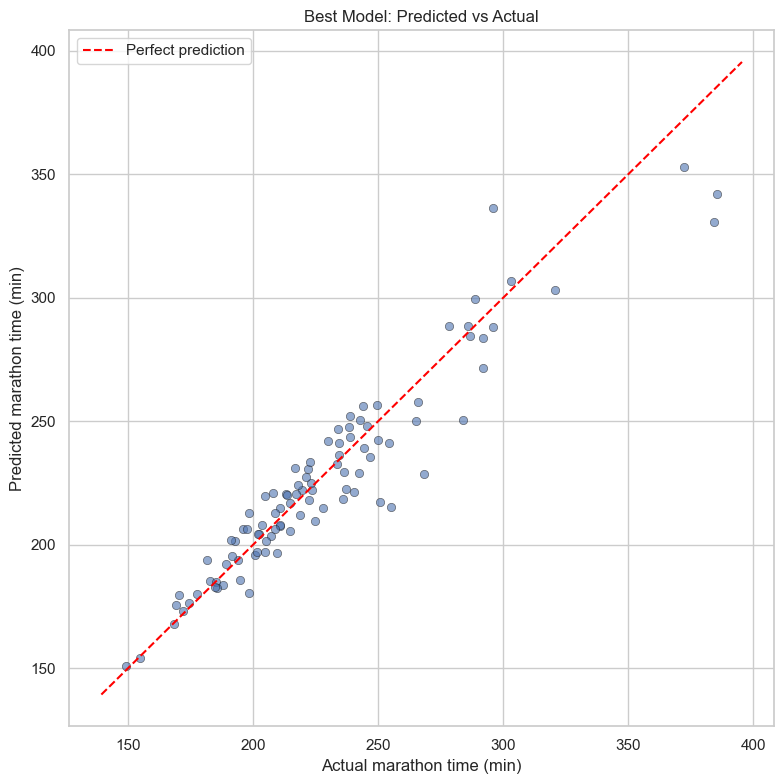

In [17]:
# Scatter plot with 1:1 line for best model
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, gb_preds, alpha=0.6, edgecolors='k', linewidth=0.5)
lims = [min(y_test.min(), gb_preds.min()) - 10, max(y_test.max(), gb_preds.max()) + 10]
ax.plot(lims, lims, '--', color='red', label='Perfect prediction')
ax.set_xlabel('Actual marathon time (min)')
ax.set_ylabel('Predicted marathon time (min)')
ax.set_title('Best Model: Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/predicted_vs_actual.png', dpi=150)
plt.show()

We've looked at this graph in the previous notebook, but its worth revisiting. Dots above the line are runners who had overpredicted times, and dots under are runners who had overpredicted times. It looks like the model rarely overpredicts by more than 10 minutes and overpredicts more than it uncerpredicts, but underpredicts values more significantly. Fit really starts to degrade after 240 (4 hour marathon). This could be because of data; we know our runners skew higher performance, and 4:00 hours is an established time people seek to beat. Data count should drop off significantly after 4 hours.

### Residual analysis

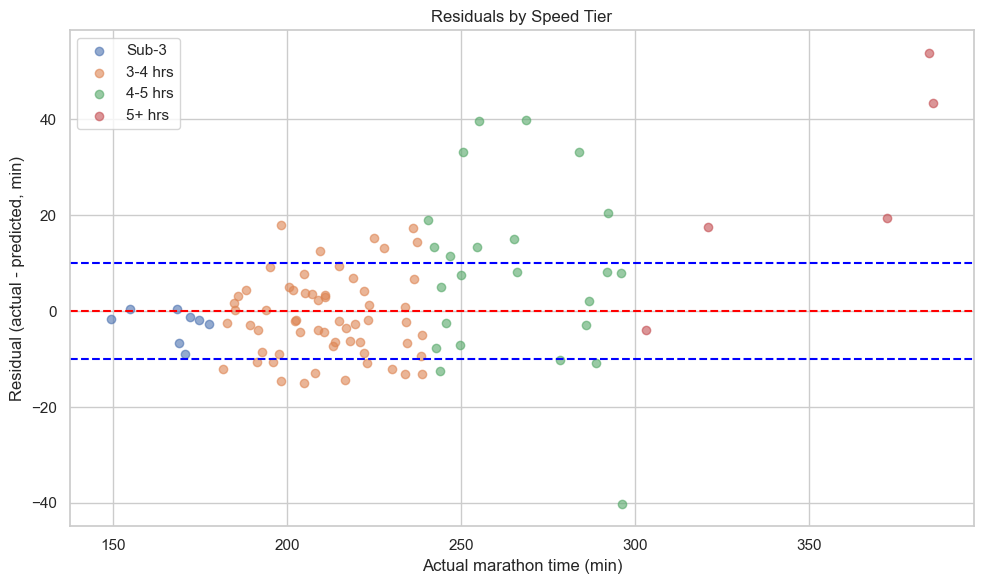

In [22]:
# Residuals colored by speed tier
residuals = y_test - gb_preds

def speed_tier(time_min):
    if time_min < 180: return 'Sub-3'
    elif time_min < 240: return '3-4 hrs'
    elif time_min < 300: return '4-5 hrs'
    else: return '5+ hrs'

tiers = y_test.apply(speed_tier)

fig, ax = plt.subplots(figsize=(10, 6))
for tier in ['Sub-3', '3-4 hrs', '4-5 hrs', '5+ hrs']:
    mask = tiers == tier
    ax.scatter(y_test[mask], residuals[mask], alpha=0.6, label=tier)
ax.axhline(y=10, color='blue', linestyle='--')
ax.axhline(y=0, color='red', linestyle='--')
ax.axhline(y=-10, color='blue', linestyle='--')
ax.set_xlabel('Actual marathon time (min)')
ax.set_ylabel('Residual (actual - predicted, min)')
ax.set_title('Residuals by Speed Tier')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/residuals_by_tier.png', dpi=150)
plt.show()

We can see more of the same here. Model mostly predicts with resudials < 10 until the 4 hour mark, where we start to frequently see resudials over 20 minutes. Its worth noting that the model still predicts accurately for some runners in the 4-5 hour group. Results in that group have a lot of variance. 

We can conclude that for runners with times 4 hours and below decending, predictions are decently accurate and better. For runners with times > 4 hours and above, predictions are poor and get worse. 

Mean residual: 2.21 min
Median residual: -1.17 min


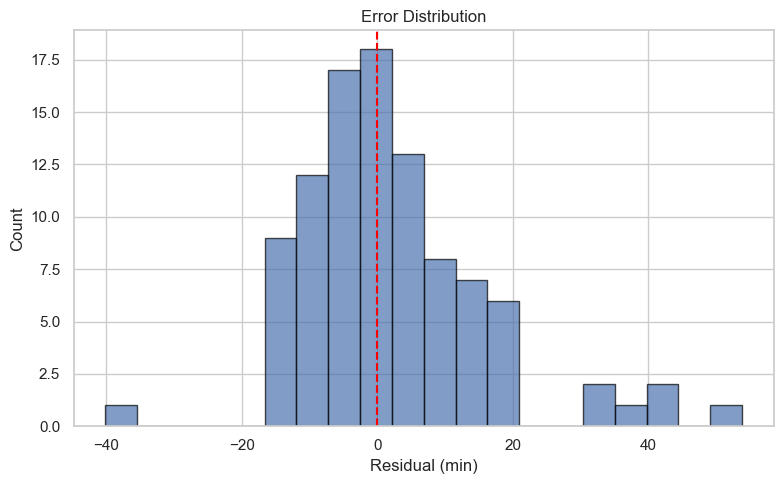

In [25]:
# Error distribution — check for symmetry / systematic bias
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--')
ax.set_xlabel('Residual (min)')
ax.set_ylabel('Count')
ax.set_title('Error Distribution')
print(f'Mean residual: {residuals.mean():.2f} min')
print(f'Median residual: {residuals.median():.2f} min')
plt.tight_layout()
plt.show()

This plot tells a similar story. Resudials are relatively normally distributed from approximately -20 to 20, ar unimodel, and centered around 0. The distribution has a cluster of overpredictions between 30 and 50 minutes on the right tail. We only have one underprediction on the left that stands out, at -40. It is settling that the better part of the resudial distributiion relatively normal; This tells me that the model isn't systemically over or underpredicting for most runners. 

Although, it is worth considering wether its better to over or underpredict someoene's marathon time. In reality, is it better for someone to stand at the start line and be overconfident or underconfident? Food for though.

### Performance by subgroup

In [20]:
# Does the model work better for fast runners vs slow runners? Men vs women?
# Group by speed tier and compute MAE per group

tier_metrics = pd.DataFrame({
    'tier': tiers,
    'abs_error': residuals.abs()
}).groupby('tier')['abs_error'].agg(['mean', 'median', 'count'])
tier_metrics.columns = ['MAE', 'Median AE', 'N']
tier_metrics

,MAE,Median AE,N
tier,,,
3-4 hrs,7.043916,6.331047,60
4-5 hrs,15.480790,11.172523,24
5+ hrs,27.595723,19.387474,5
Sub-3,2.996487,1.808246,8


This speaks to what i wasy saying earlier. Runners in the 3-4 hour group have a MAE of 7, and a Median MAE of 6.3; the fact that they are close together tells us that the model predicts these kinds of times very consistently, and doesn't produce many outliers. Its a different story in the 4-5 hour group. The difference between MAE 15.4 and Median MAE of 11.2 tell us that the model is far less reliable at accurately predicting times in the 4-5 hour band. The same is true for the 5+ hour group, only everything is exacerbated. 

The sub-3 hour group is predicted with incredible accuracy. The relative difference between MAE 3 and Median MAE 1.8 (60%) is actually the largest of any group, but the actual difference of 1.2 minutes is increcible. Our model may be predicting times in this group so well because these runners are more experienced and consistent than other runners, so their VDOT and half marathon performance are more consistent predictors of their race times.

My takeaways here are that our model is really well suited for predicting times 4 hours and below, with accuracy increasing as runners become faster. Over 4 hours things degrade quickly, and this model's predictions become useless quickly.

---

## Part 2: SHAP interpretability

Use SHAP values to explain which features matter most and in which direction they push predictions.

In [26]:
# Create SHAP explainer for the best model
# For tree-based models, use TreeExplainer (fast)
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test)

### Summary plot

Shows which features have the biggest impact overall and whether high/low values push predictions up or down.

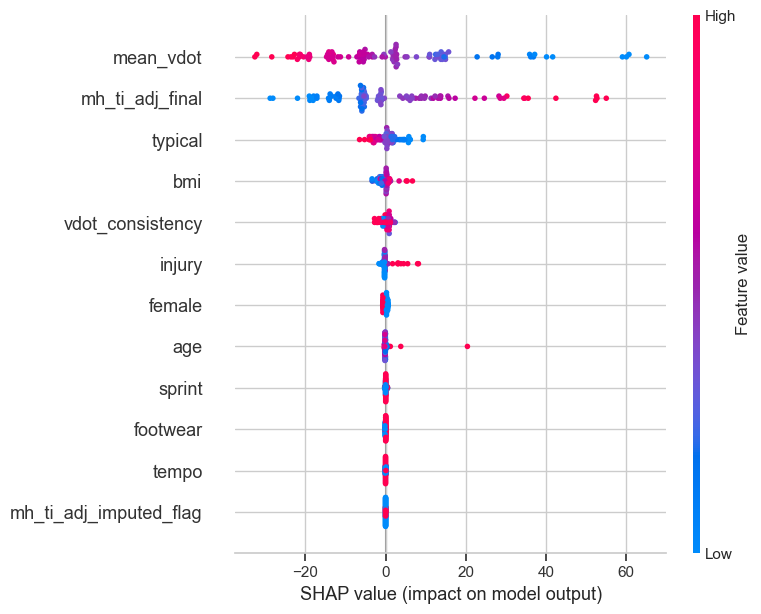

<Figure size 640x480 with 0 Axes>

In [27]:
shap.summary_plot(shap_values, X_test)
plt.savefig('../results/figures/shap_summary.png', dpi=150, bbox_inches='tight')

This plot is largely intuitive. Remarkably low VDOT scores remarkably increased predicted marathon time. Higher VDOT values regularly took 10-20 minutes off of predictded time, with some elite runners having approximately 30 minutes shaved off. Whats interesting is that the range of time added for low VDOT is greater than it is for high VDOT. Runners received a range of low vdot penalties of approximately +2 - +70 minutes for having lower VDOT's. A similar pattern emerges for half marathon times aswell. The range differences could be because we have a small range of runners with high VDOT scores but a wide range of low VDOT scores, and the same for half marathon. 

The rest of the variables had very little impact. High typial mileage intuitively predicts a faster marathon than low typical mileage. Low BMI has some predictive value but high BMI seems to be weighted a lot more in some cases. Not getting injured seems not to change predictions, but getting injured adds 0-10 minutes to predicted time. Being male adds between approximately 0-1 minute for all male runners, and the inverse for female runners. That's not a big difference in time, but it does tell us that our model predicts that female runners will be faster than men. My guess is that the model predicts that female runner with the same vdot and half marathon will be faster than a man with those same values. Finally, age doesn't have much predictive value, except for one case where the model predicted that one runners age would add 20 minutes to their time. The model may have overfit to predict that runners of a specific age run a specific time, so this is an issue.

Takeaways here are that the model adds time in a way that is intuitive for its main features, but lower-weight features training artifacts make the SHAP values hard to interpret.

### Dependence plots for top features

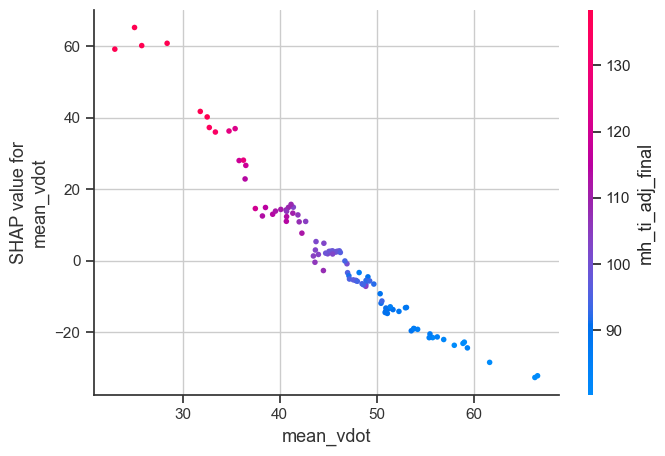

<Figure size 640x480 with 0 Axes>

In [32]:
# Dependence plot for the most important feature
shap.dependence_plot("mean_vdot", shap_values, X_test)
plt.savefig('../results/figures/shap_dependence_1.png', dpi=150, bbox_inches='tight')

Interesting that this distribution has a slight upward concave curve. It looks like there is a slight infletion point around mean vdot of 45, meaning that small changes in VDOT scores below 45 matter more than small changes in VDOT scores above 45. This relates to training maturity and running experience, and makes sense given my domain knowledge. As runners improve their VDOT between 30 and 45, they are not only gaining fitness but also race confidence, injury resistance, and a productive training mindset. VDOT's above 45 stop acting as a proxy for these tertiary benefits because those benefits are more discrete than raw fitness, and it's implied that they would already have those benefits via having trained up to that VDOT score.

But on a base level, this plot is well distributed, and those outlier points we saw before have outlier VDOT scores, so I'm less worried about overfitting. The curvature is understandable as well.

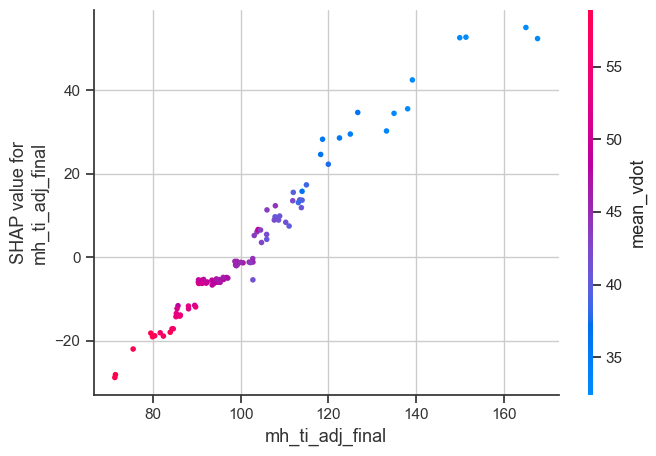

<Figure size 640x480 with 0 Axes>

In [33]:
# Dependence plot for the second most important feature
shap.dependence_plot("mh_ti_adj_final", shap_values, X_test)
plt.savefig('../results/figures/shap_dependence_2.png', dpi=150, bbox_inches='tight')

There is a strong linear, almost 1:1 correlation between time in the half marathon and predicted time in the marathon. This is completely intuitive. Outlier variables we saw in the impact plot are also outliers in terms of half marathon time, so I'm less concerned about overfitting for the half marathon feature.

### SHAP interpretation

Mean vdot and half marathon are the two driving features in my gradient boosted model. This is totally intuitive, as they both encode lots of unique and strong information. Other variables like typical mileage, BMI, and injury have a small but quantifiable impact on predicting marathon time. The only real suprise is how the model consistently predicts that female runners will run faster than male runners, although this could be because of confounding factors with mean vdot and half marathon as discussed prior. The only real outlier that makes me worry about overfitting is the one runner who had 20 minutes added to their time because of age; the model probably overfit to one runner's age and now predicts that runners of that age are significantly slower than all other runners. Other than this one datapoint, the model's logic meshes well and lines up with my knowledge of marathon training.

---

## Part 3: Personal Strava validation

Test the model on your own training data as an n=1 case study. This is narrative, not statistical evidence.

In [35]:
# Load your Strava export
strava = pd.read_json('../data/raw/strava_data.jsonl', lines=True)
strava.head()

,resource_state,athlete,name,distance,moving_time,elapsed_time,total_elevation_gain,type,sport_type,workout_type,...,display_hide_heartrate_option,elev_high,elev_low,upload_id,upload_id_str,external_id,from_accepted_tag,pr_count,total_photo_count,has_kudoed
0,2,"{'id': 105437508, 'resource_state': 1}",Lunch Run,7383.3,2701,2789,36.1,Run,Run,NaN,...,True,81.7,65.2,1.789724e+10,1.789724e+10,garmin_ping_515055148032,False,0,0,False
1,2,"{'id': 105437508, 'resource_state': 1}",Evening Run,6804.4,2701,2848,38.6,Run,Run,NaN,...,True,81.6,65.2,1.784502e+10,1.784502e+10,garmin_ping_513079338936,False,0,0,False
2,2,"{'id': 105437508, 'resource_state': 1}",Afternoon Run,7709.8,2686,2737,2.2,Run,Run,NaN,...,True,6.1,2.6,1.784485e+10,1.784485e+10,garmin_ping_513070044221,False,1,0,False
3,2,"{'id': 105437508, 'resource_state': 1}",Afternoon Run,8342.4,3158,3219,4.2,Run,Run,NaN,...,True,6.5,3.6,1.784485e+10,1.784485e+10,garmin_ping_513070012707,False,3,0,False
4,2,"{'id': 105437508, 'resource_state': 1}",Evening Run,3225.6,1245,1262,0.0,Run,Run,NaN,...,True,0.0,0.0,1.784485e+10,1.784485e+10,garmin_ping_513069956216,False,0,0,False


In [ ]:
# Filter to the 16 weeks before your marathon
# marathon_date = pd.Timestamp('YYYY-MM-DD')  # fill in your race date
# training_start = marathon_date - pd.Timedelta(weeks=16)
# training_block = strava[
#     (strava['date'] >= training_start) & (strava['date'] < marathon_date)
# ]

In [ ]:
# Calculate the features your model expects
# avg_weekly_mileage = ...
# longest_run = ...
# avg_pace = ...
# half_marathon_time = ...  # from a race in that period, if you have one
# print(f'Avg weekly mileage: {avg_weekly_mileage:.1f}')
# print(f'Longest run: {longest_run:.1f}')

In [ ]:
# Build a single-row DataFrame matching your feature columns
# my_features = pd.DataFrame([{
#     # fill in your feature values here
# }])

# Run predictions
# my_model_pred = gb_model.predict(my_features)[0]
# my_riegel_pred = riegel_predict(half_marathon_time, 21.0975, 42.195)
# my_actual = ...  # your actual marathon finish time in minutes

# print(f'Model prediction:  {my_model_pred:.1f} min')
# print(f'Riegel prediction: {my_riegel_pred:.1f} min')
# print(f'Actual time:       {my_actual:.1f} min')
# print(f'Model error:       {my_model_pred - my_actual:.1f} min')
# print(f'Riegel error:      {my_riegel_pred - my_actual:.1f} min')

### Personal validation writeup

*"My model predicted X, Riegel predicted Y, I actually ran Z." Explain any discrepancy — race-day conditions, pacing decisions, fitness changes in the final weeks, etc. Note that this is n=1 and not statistically meaningful.*

---

## Part 4: Error analysis and model limitations

### Worst predictions

In [ ]:
# Identify the 10 worst predictions
# error_df = test.copy()
# error_df['predicted'] = gb_preds
# error_df['abs_error'] = (error_df['marathon_time'] - error_df['predicted']).abs()
# worst_10 = error_df.nlargest(10, 'abs_error')
# worst_10[['marathon_time', 'predicted', 'abs_error'] + feature_cols]

### Pattern in worst predictions

*Is there a pattern? Are the worst predictions all very fast runners? Very slow? Runners with missing/imputed data? Document what you find.*

### Known limitations

- **Self-reported data:** Vickers dataset is survey-based with no independent verification of race times or training volumes.
- **No race-day conditions:** The model has no weather, course difficulty, or altitude features.
- **No pacing strategy data:** How a runner executes the race (positive/negative split) is a major factor not captured here.
- **Small dataset:** ~493 usable runners limits the model's ability to learn complex patterns and generalize.
- **Selection bias:** Survey respondents are more engaged, experienced runners — the model may not generalize to casual first-time marathoners.
- **Missing half marathon data:** ~22% of half marathon times were imputed via Riegel formula, introducing a fixed-formula assumption into a portion of the training data.

### What would improve this with more time?

*Discuss concrete next steps:*
- *Link Afonseca training logs to scraped race results (probabilistic matching by demographics and predicted finish time)*
- *Add race-day weather features via Open-Meteo API*
- *Build Strava API integration to collect training data from consenting runners*
- *Use Bayesian or sequence modeling over training trajectories*
- *Conformal prediction or quantile regression for uncertainty quantification*

---

## Key findings

*Summarize the main takeaways from this notebook in 3-5 sentences. Which model won? By how much over Riegel? What does SHAP tell you? How did the personal validation go?*